# Exercises

(Date - 10/June/2026)

In [88]:
import torch
from torch import nn
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import requests
import zipfile
from pathlib import Path
import random
from PIL import Image
import matplotlib.pyplot as plt
from typing import List
from tqdm.auto import tqdm
from timeit import default_timer as Timer
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

Answer: 
1. Increase the complexity of model: 
Adding more hidden layers/units allow the model to fit well to the training data.

2. Train for longer:
Increasing the no. of epochs allow the model to find useful patterns in data and perform better.

3. Tweak the learning rate:
If the learning rate is too low, then the model will take forever to get trained. If it is too much, then the model will act like a maniac. So use tweak the learning rate to find the best one for your model training.

In [ ]:
data_path = Path("FoodData_Exercise")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"Directory {image_path} already exists... No need for downloading")
else:
    print(f"{image_path} doesn't exist... Making one...")
    image_path.mkdir(parents=True, exist_ok=True)
    image_path_zip = data_path / "pizza_steak_sushi.zip"
    
    with open(image_path_zip, "wb") as f:
        print(f"Downloading data...")
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
        f.write(request.content)

    with zipfile.ZipFile(image_path_zip, "r") as zip_ref:
        print("Unzipping data")
        zip_ref.extractall(image_path)

Directory FoodData_Exercise\pizza_steak_sushi already exists... No need for downloading


In [43]:
data_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor()
])

In [44]:
def plot_tranformed_image(image_paths, transform, n=3, seed=None):
    if seed:
        random.seed(seed)
    
    random_image_paths = random.sample(image_paths, k=n)
    
    for image_path in random_image_paths:
        with Image.open(image_path) as f:
            fig, ax = plt.subplots(nrows=1, ncols=2)
            
            ax[0].imshow(f)
            ax[0].set_title(f"Original\nsize: {f.size}")
            ax[0].axis("off")

            transformed_image = transform(f).permute(1,2,0)
            ax[1].imshow(f)
            ax[1].set_title(f"Transformed\nsize: {transformed_image.shape}")
            ax[1].axis("off")

            fig.suptitle(f"Class : {image_path.parent.stem}", fontsize=16)

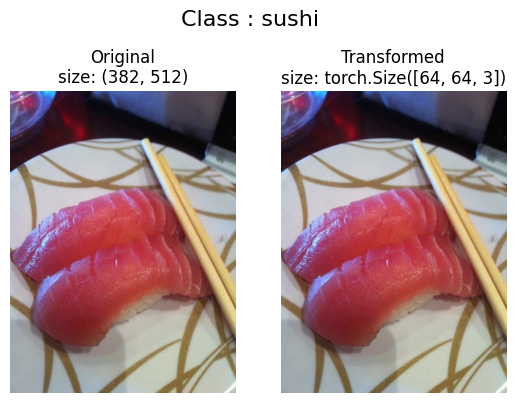

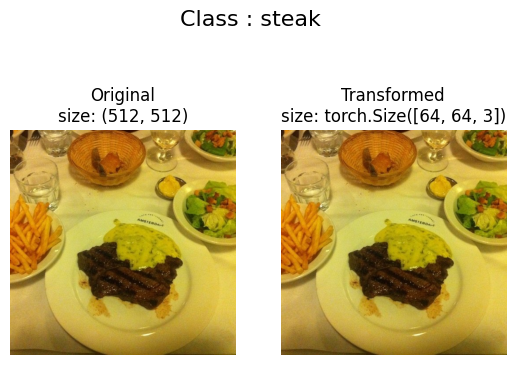

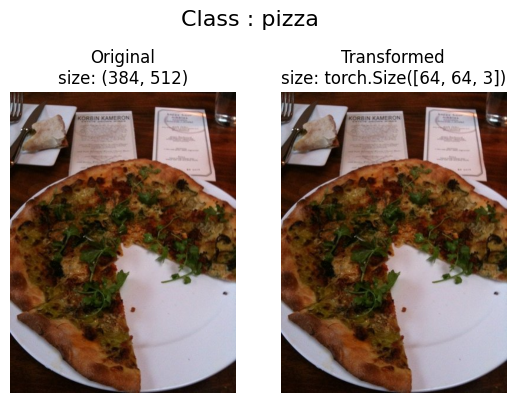

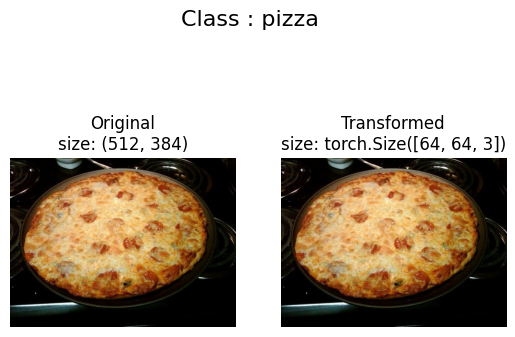

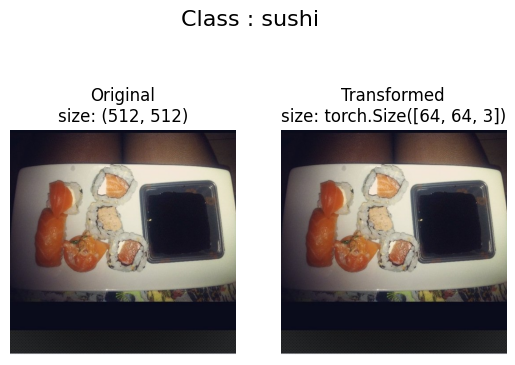

In [45]:
image_path_list = list(image_path.glob("*/*/*.jpg"))

plot_tranformed_image(image_paths=image_path_list,
                      n = 5,
                      seed=None,
                      transform = data_transform)

In [46]:
train_dir = image_path / "train"
test_dir = image_path / "test"

training_data = datasets.ImageFolder(root=train_dir,
                                     transform = data_transform,
                                     target_transform=None)

testing_data = datasets.ImageFolder(root=test_dir,
                                    transform = data_transform)

In [47]:
class_names = training_data.classes
class_names

['pizza', 'steak', 'sushi']

In [48]:
training_dataloader = DataLoader(dataset=training_data,
                                 shuffle=True,
                                 batch_size=1,
                                 num_workers=1)

testing_dataloader = DataLoader(dataset=testing_data,
                          shuffle=False,
                          batch_size=1,
                          num_workers=1)

3. Recreate model_0 we built in section 7.

In [64]:
class TinyVGGModel_0(nn.Module):
    def __init__(self,
                 input_shape,
                 hidden_units,
                 output_shape):
        super().__init__()

        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),

            nn.Tanh(),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.Tanh(),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
            )
        
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, 
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),

            nn.Tanh(),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      padding=1,
                      stride=1),
            nn.Tanh(),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
            )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*256,
                       out_features=output_shape)
        )

    def forward(self, x):
        return self.classifier(self.conv_block_2(self.conv_block_1(x)))

model_0 = TinyVGGModel_0(input_shape=3,
                         hidden_units=20,
                         output_shape=len(class_names)).to(device)

4. Create training and testing functions for model_0.

In [65]:
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device):
    model.train()
    loss, acc = 0, 0

    for batch, (img, true_label) in enumerate(data_loader):
        img, true_label = img.to(device), true_label.to(device)
        
        label_pred = model(img)

        temp_loss = loss_fn(label_pred, true_label)
        loss+=temp_loss

        label_pred_class = torch.argmax(torch.softmax(label_pred, dim=1), dim=1)
        acc += ((label_pred_class==true_label).sum().item() / len(label_pred)) * 100 
        
        optimizer.zero_grad()
        temp_loss.backward()
        optimizer.step()
    
    DataLoader_length = len(data_loader)
    loss = loss / DataLoader_length
    acc = acc / DataLoader_length

    return loss, acc



In [66]:
def test_step(model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              device):
    model.eval()
    loss, acc = 0, 0

    with torch.inference_mode():
        for batch, (img, true_label) in enumerate(data_loader):
            img, true_label = img.to(device), true_label.to(device)

            pred_label = model(img)

            temp_loss = loss_fn(pred_label, true_label)
            loss+=temp_loss

            label_pred_class = torch.argmax(torch.softmax(pred_label, dim=1), dim=1)
            acc+= ((label_pred_class==true_label).sum().item() / len(pred_label)) * 100
    
    data_loader_length = len(data_loader)
    loss = loss / data_loader_length
    acc = acc / data_loader_length

    return loss, acc

In [67]:
def training(model: torch.nn.Module,
             train_dataloader: torch.utils.data.DataLoader,
             test_dataloader: torch.utils.data.DataLoader,
             loss_fn: torch.nn.Module,
             optimizer: torch.optim.Optimizer,
             device,
             epochs: int):
    
    results = {
        "train_loss" : [],
        "train_acc" : [],
        "test_loss" : [],
        "test_acc" : [],
               }
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                   data_loader=train_dataloader,
                                   loss_fn=loss_fn,
                                   optimizer=optimizer,
                                   device=device
                                   )
        
        test_loss, test_acc = test_step(model=model,
                                 data_loader=test_dataloader,
                                 loss_fn=loss_fn,
                                 device=device)
        
        print(f"epoch : {epoch + 1} | "
            f"train_loss : {train_loss:.4f} | "
            f"train_acc : {train_acc:.2f} | "
            f"test_loss : {test_loss:.4f} | "
            f"test_acc : {test_acc:.2f} | ")
              
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    return results

In [68]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(params=model_0.parameters(),
                             lr=0.001)

In [71]:
train_start_time = Timer()

training(model=model_0,
         train_dataloader=training_dataloader,
         test_dataloader=testing_dataloader,
         loss_fn=loss_fn,
         optimizer=optimizer,
         device=device,
         epochs=3)

train_end_time = Timer()
total_train_time = train_end_time - train_start_time

print(f"Total training time : {total_train_time} seconds")

 33%|███▎      | 1/3 [00:15<00:31, 15.72s/it]

epoch : 1 | train_loss : 1.0990 | train_acc : 34.67 | test_loss : 1.1003 | test_acc : 33.33 | 


 67%|██████▋   | 2/3 [00:33<00:17, 17.02s/it]

epoch : 2 | train_loss : 1.0990 | train_acc : 34.67 | test_loss : 1.1008 | test_acc : 33.33 | 


100%|██████████| 3/3 [00:49<00:00, 16.57s/it]

epoch : 3 | train_loss : 1.0990 | train_acc : 34.22 | test_loss : 1.1010 | test_acc : 33.33 | 
Total training time : 49.72205179999946 seconds


5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?
* Use torch.optim.Adam() with a learning rate of 0.001 as the optimizer.

Answer:
Model takes more time to run but its performance improves.

6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?
Answer : Not a big change in both, time taken (to train) and model's performance. (Although time taken to train increased slightly).

7. Double the data you're using with your model and train it for 20 epochs, what happens to the results?
* Note: You can use the custom data creation notebook to scale up your Food101 dataset.
* You can also find the already formatted double data (20% instead of 10% subset) dataset on GitHub, you will need to write download code like in exercise 2 to get it into this notebook

In [ ]:
data_path = Path("FoodData_Exercise_20_percent")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
    print(f"{image_path} already exists... Skipping download")
    image_path_zip = data_path / "pizza_steak_sushi.zip"
else:
    print(f"{image_path} doesn't exist... Creating one...")
    image_path.mkdir(parents=True, exist_ok=True)

    with open(image_path_zip, "wb") as f:
        print("Downloading data...")
        request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip")
        f.write(request.content)
    
    with zipfile.ZipFile(image_path_zip, "r") as zip_ref:
        print("Extracting...")
        zip_ref.extractall(image_path)
    
    print("Everything Done!")

Extracting...
Everything Done!


In [76]:
train_data_20_path = image_path / "train"
test_data_20_path = image_path / "test"

simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

train_data_20 = datasets.ImageFolder(root=train_data_20_path,
                                     transform=simple_transform,
                                     target_transform=None)

test_data_20 = datasets.ImageFolder(root=train_data_20_path,
                                    transform=simple_transform)

train_dataloader_20 = DataLoader(dataset=train_data_20,
                                 shuffle=True,
                                 batch_size=1,
                                 num_workers=1)

testing_dataloader_20 = DataLoader(dataset=test_data_20,
                                   shuffle=False,
                                   batch_size=1,
                                   num_workers=1)

In [77]:
train_start_time_20 = Timer()

training(model=model_0,
         train_dataloader=train_dataloader_20,
         test_dataloader=testing_dataloader_20,
         loss_fn=loss_fn,
         optimizer=optimizer,
         device=device,
         epochs=5)

train_end_time_20 = Timer()
total_train_time_20 = train_end_time_20 - train_start_time_20

print(f"Total training time: {total_train_time_20} seconds")

 20%|██        | 1/5 [00:24<01:38, 24.73s/it]

epoch : 1 | train_loss : 1.0992 | train_acc : 34.22 | test_loss : 1.0984 | test_acc : 34.22 | 


 40%|████      | 2/5 [00:44<01:04, 21.56s/it]

epoch : 2 | train_loss : 1.0993 | train_acc : 34.00 | test_loss : 1.0849 | test_acc : 46.22 | 


 60%|██████    | 3/5 [01:03<00:40, 20.44s/it]

epoch : 3 | train_loss : 1.0468 | train_acc : 50.89 | test_loss : 0.9740 | test_acc : 55.33 | 


 80%|████████  | 4/5 [01:22<00:20, 20.02s/it]

epoch : 4 | train_loss : 0.9332 | train_acc : 57.33 | test_loss : 0.8282 | test_acc : 65.56 | 


100%|██████████| 5/5 [01:42<00:00, 20.42s/it]

epoch : 5 | train_loss : 0.8476 | train_acc : 64.89 | test_loss : 0.8088 | test_acc : 63.11 | 
Total training time: 102.09188360000007 seconds


8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) and share your prediction.
* Does the model you trained in exercise 7 get it right?
* If not, what do you think you could do to improve it?

In [82]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device=device):
    """Makes a prediction on a target image and plots the image with its prediction."""
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32) / 255

    if transform is not None:
        target_image = transform(target_image)
    
    model.to(device)

    model.eval()
    with torch.inference_mode():
        target_image = target_image.unsqueeze(0)
        target_image_pred = model(target_image.to(device))
    
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)
    target_image_pred_labels = torch.argmax(target_image_pred_probs, dim=1)

    plt.imshow(target_image.squeeze().permute(1,2,0))
    if class_names:
        title = f"Prediction : {class_names[target_image_pred_labels.cpu()]} | Probability : {target_image_pred_probs.max().cpu():.3f}"

    else:
        title = f"Prediction: {target_image_pred_labels} | Probability: {target_image_pred_probs.max().cpu():.3f}"
    
    plt.title(title)
    plt.axis("off")

In [84]:
custom_transform = transforms.Compose([
    transforms.Resize(size=(64,64))
])

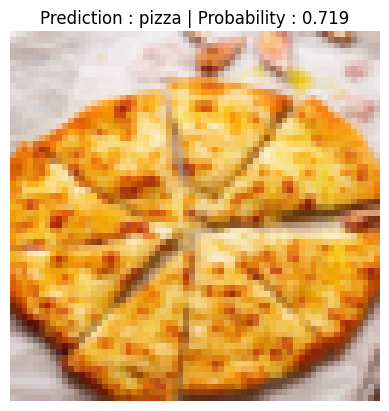

In [85]:
pred_and_plot_image(image_path="FoodData/Custom_images_for_testing/Custom_pizza_1.jfif",
                    model=model_0,
                    class_names = class_names,
                    transform=custom_transform,
                    device=device)

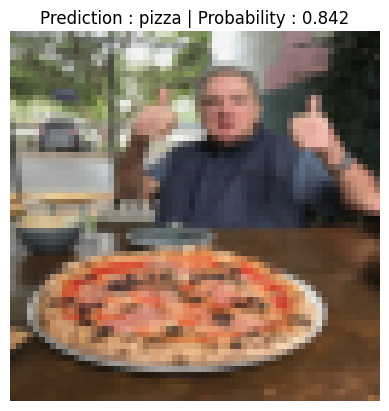

In [86]:
pred_and_plot_image(image_path="FoodData/Custom_images_for_testing/04-pizza-daniel_dad.jpeg",
                    model=model_0,
                    class_names = class_names,
                    transform=custom_transform,
                    device=device)

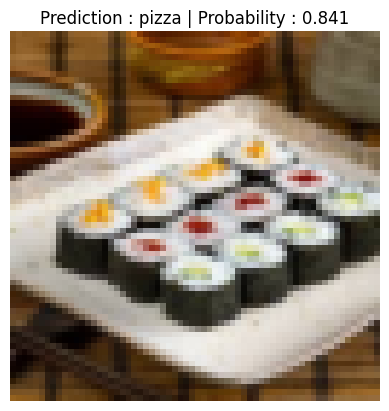

In [87]:
pred_and_plot_image(image_path="FoodData/Custom_images_for_testing/Custom_sushi_1.jfif",
                    model=model_0,
                    class_names = class_names,
                    transform=custom_transform,
                    device=device)